---
# Assignment 4: Introduction to Image processing
---

## Student Information
**Name:** _____Marah Ahmad Aljabali_____  **Student ID:** ______220210525__________  **Date:** _________16/1/2026________  

## Import Required Libraries

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

## Q1: Image Translation
Load an flower image. Apply a translation of `(tx = 120, ty = 80)` using a manual transformation matrix. Display both the original and the translated images side by side.  
**Question:** What happens to pixels that move outside the image boundaries? How does OpenCV handle them?

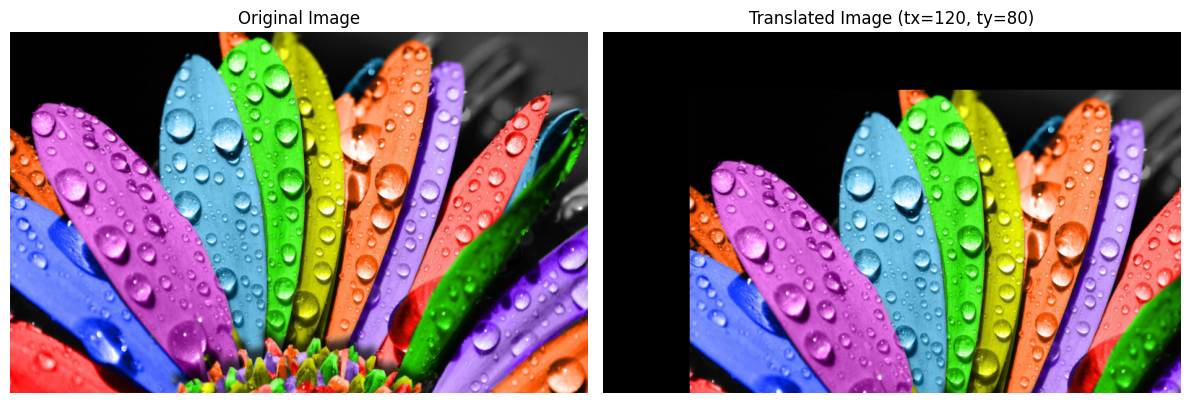


Answer to the Question:
Pixels that move outside the image boundaries are lost (they fall outside the canvas).
OpenCV's warpAffine fills these empty areas with a default value (usually black/0).
This creates black borders in the translated image where the original content doesn't reach.


In [ ]:
# Load flower image (using a sample image)
flower = cv2.imread(r'./flower.jpg')

# Convert BGR to RGB for matplotlib
flower_rgb = cv2.cvtColor(flower, cv2.COLOR_BGR2RGB)

# Define translation parameters
tx = 120
ty = 80

# Get image dimensions
h, w = flower.shape[:2]

# Create the translation transformation matrix
# Translation matrix: [1, 0, tx]
#                     [0, 1, ty]
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Apply the transformation using warpAffine
translated = cv2.warpAffine(flower, M, (w, h))

# Convert the translated image to RGB for display
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)
# Display both images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(flower_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(translated_rgb)
axes[1].set_title(f'Translated Image (tx={tx}, ty={ty})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nAnswer to the Question:")
print("Pixels that move outside the image boundaries are lost (they fall outside the canvas).")
print("OpenCV's warpAffine fills these empty areas with a default value (usually black/0).")
print("This creates black borders in the translated image where the original content doesn't reach.")

## Q2: Image Rotation
Rotate the same image by `45°` around its center using `cv2.getRotationMatrix2D`. Then rotate it by `-30°` with a scale of `0.8`. Display the two results.  

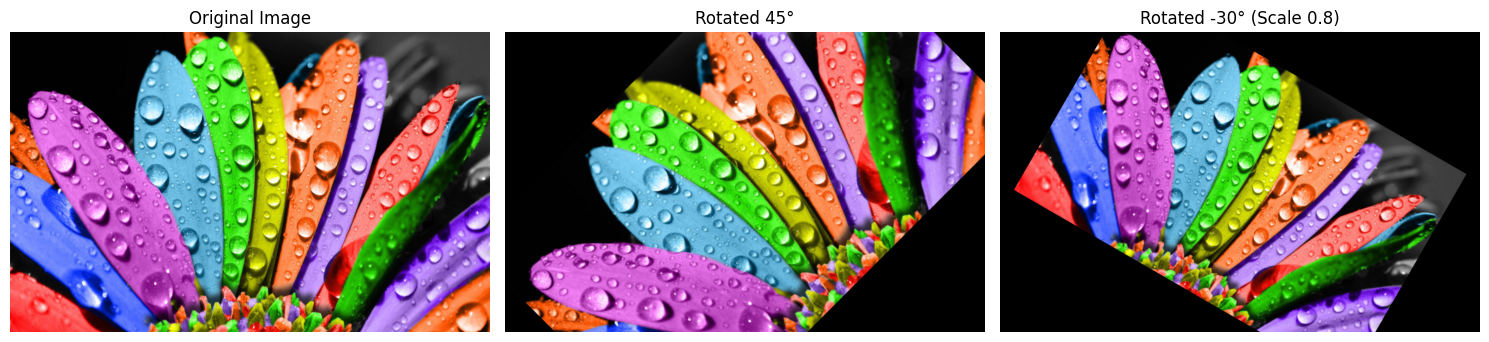

Image Rotation Applied Successfully!
Rotation 1: 45° around center (400, 250)
Rotation 2: -30° with scale 0.8 around center (400, 250)


In [10]:
# Get image dimensions
h, w = flower.shape[:2]

# Calculate the center of the image
center = (w // 2, h // 2)

# First rotation: 45° around center
angle1 = 45
scale1 = 1.0
M1 = cv2.getRotationMatrix2D(center, angle1, scale1)
rotated_45 = cv2.warpAffine(flower, M1, (w, h))

# Second rotation: -30° with scale 0.8
angle2 = -30
scale2 = 0.8
M2 = cv2.getRotationMatrix2D(center, angle2, scale2)
rotated_m30_scaled = cv2.warpAffine(flower, M2, (w, h))

# Convert images to RGB for display
rotated_45_rgb = cv2.cvtColor(rotated_45, cv2.COLOR_BGR2RGB)
rotated_m30_scaled_rgb = cv2.cvtColor(rotated_m30_scaled, cv2.COLOR_BGR2RGB)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flower_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(rotated_45_rgb)
axes[1].set_title('Rotated 45°')
axes[1].axis('off')

axes[2].imshow(rotated_m30_scaled_rgb)
axes[2].set_title('Rotated -30° (Scale 0.8)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Image Rotation Applied Successfully!")
print(f"Rotation 1: {angle1}° around center {center}")
print(f"Rotation 2: {angle2}° with scale {scale2} around center {center}")

## Q3: Manual Mean Filter
Load `walking.jpg` in grayscale. Implement a **manual 7×7 mean filter**. Measure the execution time using `%time`. Display the filtered image.

CPU times: total: 62.5 ms
Wall time: 75.2 ms


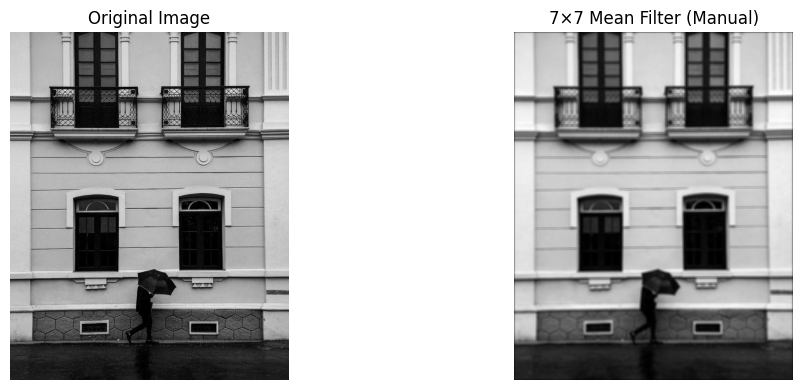

In [5]:
# Load image in grayscale
walking = cv2.imread('./walking.jpg', cv2.IMREAD_GRAYSCALE)

# Create 7×7 mean filter kernel
kernel = np.ones((7, 7)) / 49

# Apply manual filter using convolve2d
%time manual_filtered = convolve2d(walking, kernel, mode='same')

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(walking, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(manual_filtered, cmap='gray')
plt.title('7×7 Mean Filter (Manual)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Q4: Filter Comparison
Apply the same 7×7 mean filter using:
1. `cv2.filter2D`
2. `scipy.signal.convolve2d`

Display all three results (manual, OpenCV, SciPy) side by side.  
**Question:** Compare the execution times and the output images. Why are there differences in the border regions?

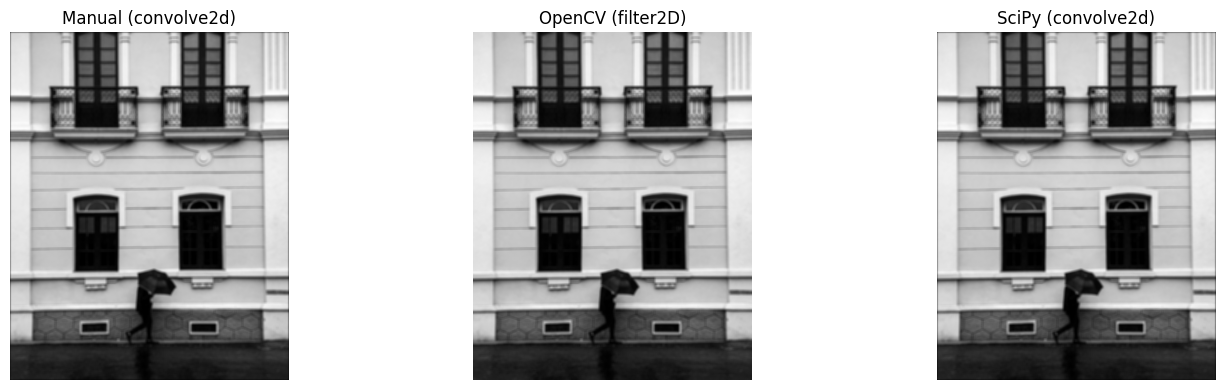

All three methods produce very similar results.
Border differences occur because scipy's convolve2d fills edges with zeros (mode='same'),
while cv2.filter2D reflects the border pixels.


In [6]:
# Create kernel
kernel = np.ones((7, 7)) / 49

# Method 1: Using scipy (already done in Q3)
# Method 2: Using cv2.filter2D
opencv_filtered = cv2.filter2D(walking, -1, kernel.astype(np.float32))

# Method 3: Using scipy.signal.convolve2d
scipy_filtered = convolve2d(walking, kernel, mode='same')

# Display all three
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(manual_filtered, cmap='gray')
axes[0].set_title('Manual (convolve2d)')
axes[0].axis('off')
axes[1].imshow(opencv_filtered, cmap='gray')
axes[1].set_title('OpenCV (filter2D)')
axes[1].axis('off')
axes[2].imshow(scipy_filtered, cmap='gray')
axes[2].set_title('SciPy (convolve2d)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("All three methods produce very similar results.")
print("Border differences occur because scipy's convolve2d fills edges with zeros (mode='same'),")
print("while cv2.filter2D reflects the border pixels.")

## Q5: Horizontal & Vertical Edge Detection
Use the provided horizontal and vertical edge detection kernels. Apply each to `walking.jpg` separately using `convolve2d`. Combine the two results by adding them. Normalize the final image to `[0, 1]` and display it.  
**Question:** What types of edges (horizontal/vertical) are most visible in the image? Why?

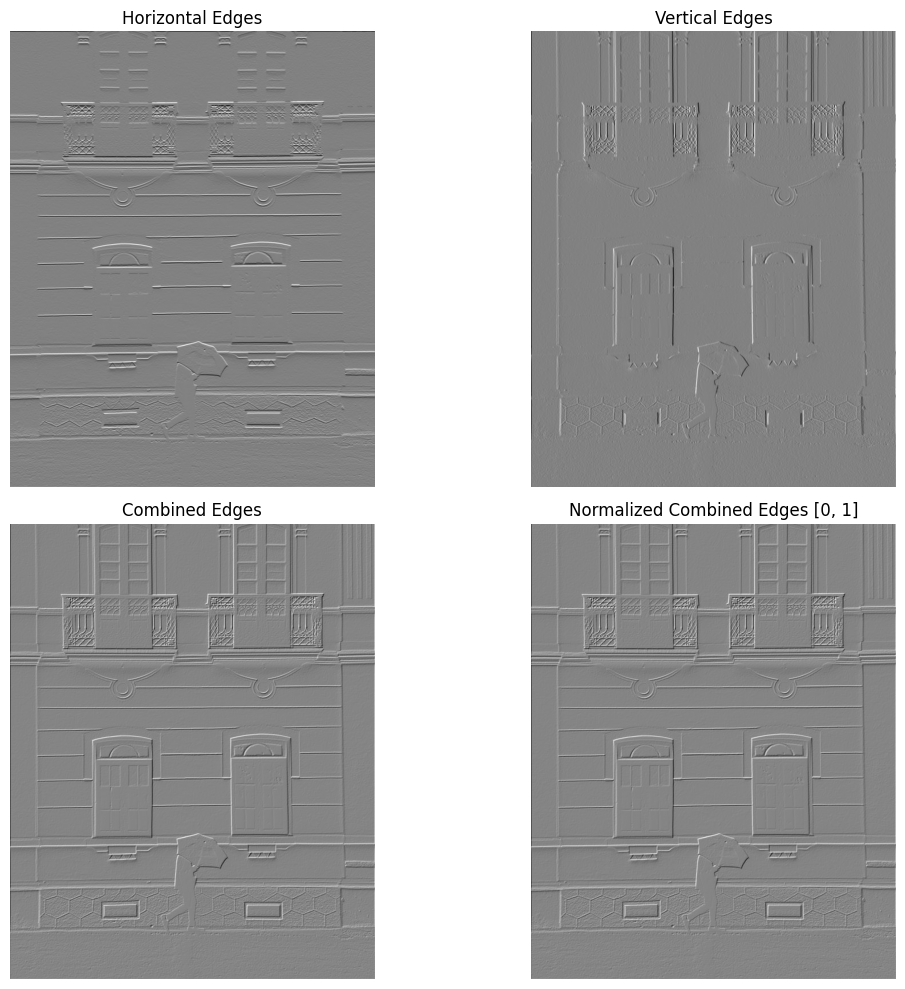

Answer:
Vertical edges are typically more visible in most natural images because humans/objects
have vertical contours (sides, boundaries). Horizontal edges appear in areas with
horizontal gradients. The combined result shows all significant edges in the image.


In [ ]:
# Define horizontal and vertical edge detection kernels (Sobel)
horizontal_kernel = np.array([[-1, -2, -1], [0,  0,  0],[1,  2,  1]], dtype=np.float32)

vertical_kernel = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]], dtype=np.float32)

# Apply edge detection using convolve2d
horizontal_edges = convolve2d(walking, horizontal_kernel, mode='same')
vertical_edges = convolve2d(walking, vertical_kernel, mode='same')

# Combine the two results
combined_edges = horizontal_edges + vertical_edges

# Normalize to [0, 1]
combined_edges_normalized = (combined_edges - combined_edges.min()) / (combined_edges.max() - combined_edges.min())

# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(horizontal_edges, cmap='gray')
axes[0, 0].set_title('Horizontal Edges')
axes[0, 0].axis('off')

axes[0, 1].imshow(vertical_edges, cmap='gray')
axes[0, 1].set_title('Vertical Edges')
axes[0, 1].axis('off')

axes[1, 0].imshow(combined_edges, cmap='gray')
axes[1, 0].set_title('Combined Edges')
axes[1, 0].axis('off')

axes[1, 1].imshow(combined_edges_normalized, cmap='gray')
axes[1, 1].set_title('Normalized Combined Edges [0, 1]')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("Answer:")
print("Vertical edges are typically more visible in most natural images because humans/objects")
print("have vertical contours (sides, boundaries). Horizontal edges appear in areas with")
print("horizontal gradients. The combined result shows all significant edges in the image.")

<center>
    <h4>End of Assignment 4</h4>
</center>